In [ ]:
import h5py
import halotools
import os
import copy
import warnings
import numpy as np
import math
from astropy.modeling import Fittable1DModel, Parameter,models,fitting
import pickle
import warnings
import numpy.ma as ma
import pandas as pd
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import spearmanr,kendalltau,pearsonr
import palettable
import deepdish as dd
import matplotlib.cm as cm
import pingouin as pg
import matplotlib

from matplotlib.collections import LineCollection
from photutils.isophote import EllipseGeometry
from photutils.aperture import EllipticalAperture,EllipticalAnnulus
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from matplotlib import colors
from astroML.stats import binned_statistic_2d
from scipy.ndimage.filters import gaussian_filter

from astropy.utils.console import ProgressBar
from astropy.table import QTable,hstack
plt.rc('text', usetex=True)
rcParams.update({'axes.linewidth': 1.5})
rcParams.update({'xtick.direction': 'in'})
rcParams.update({'ytick.direction': 'in'})
rcParams.update({'xtick.minor.visible': 'True'})
rcParams.update({'ytick.minor.visible': 'True'})
rcParams.update({'xtick.major.pad': '7.0'})
rcParams.update({'xtick.major.size': '8.0'})
rcParams.update({'xtick.major.width': '1.5'})
rcParams.update({'xtick.minor.pad': '7.0'})
rcParams.update({'xtick.minor.size': '4.0'})
rcParams.update({'xtick.minor.width': '1.5'})
rcParams.update({'ytick.major.pad': '7.0'})
rcParams.update({'ytick.major.size': '8.0'})
rcParams.update({'ytick.major.width': '1.5'})
rcParams.update({'ytick.minor.pad': '7.0'})
rcParams.update({'ytick.minor.size': '4.0'})
rcParams.update({'ytick.minor.width': '1.5'})
rcParams.update({'axes.titlepad': '10.0'})
rcParams.update({'font.size': 35})

/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_57020/581672285.py:31: DeprecationWarning: Please use `gaussian_filter` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  from scipy.ndimage.filters import gaussian_filter


/Users/xushuo/miniconda3/envs/tardis/lib/python3.8/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.1, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [2]:
fig_dir="/Users/xushuo/work/Papers/CenvsSat/Figure/"
data_dir='/Users/xushuo/work/Submit/CenvsSat/Data/'

In [3]:
with open(data_dir+"galaxies_tng300_072_hmc_13_aperture_mass.txt",'rb') as f: 
    tab=pickle.load(f)
mask=(tab['proj']=='xy')
tab1=tab[mask]
with open(data_dir+"galaxies_tng300_072_hmc_13_richness_satellite_mass.txt",'rb') as f: 
    tab_rich0=pickle.load(f)
with open(data_dir+"galaxies_tng300_072_hmc_13_cylinder_richness_satellite_mass.txt",'rb') as f: 
    tab_rich=pickle.load(f)
tab2=hstack([tab[mask],tab_rich0[tab_rich0.colnames[2:]],tab_rich[tab_rich.colnames[2:]]])

In [4]:
cmap1=palettable.lightbartlein.diverging.BlueDarkRed18_10.mpl_colormap

In [5]:
def heatmap(data, row_labels, col_labels, ax=None,grid_off=True,fontsize=30,
            cbar_kw={}, cbarlabel="", **kwargs):
    """
    Create a heatmap from a numpy array and two lists of labels.

    Parameters
    ----------
    data
        A 2D numpy array of shape (M, N).
    row_labels
        A list or array of length M with the labels for the rows.
    col_labels
        A list or array of length N with the labels for the columns.
    ax
        A `matplotlib.axes.Axes` instance to which the heatmap is plotted.  If
        not provided, use current axes or create a new one.  Optional.
    cbar_kw
        A dictionary with arguments to `matplotlib.Figure.colorbar`.  Optional.
    cbarlabel
        The label for the colorbar.  Optional.
    **kwargs
        All other arguments are forwarded to `imshow`.
    """

    if not ax:
        ax = plt.gca()

    # Plot the heatmap
    im = ax.imshow(data, **kwargs)

    # Create colorbar
    cbar = ax.figure.colorbar(im, ax=ax, **cbar_kw)
    cbar.ax.set_ylabel(cbarlabel, rotation=-90, va="bottom")

    # Show all ticks and label them with the respective list entries.
    ax.set_xticks(np.arange(data.shape[1]), labels=col_labels,fontsize=fontsize)
    ax.set_yticks(np.arange(data.shape[0]), labels=row_labels,fontsize=fontsize)

    # Let the horizontal axes labeling appear on top.
    #ax.tick_params(top=True, bottom=False,
                   #labeltop=True, labelbottom=False)

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=-30, ha="left",
             rotation_mode="anchor")

    # Turn spines off and create white grid.
    if grid_off==False:
        ax.spines[:].set_visible(False)

        ax.set_xticks(np.arange(data.shape[1]+1)-.5, minor=True)
        ax.set_yticks(np.arange(data.shape[0]+1)-.5, minor=True)
        ax.grid(which="minor", color="w", linestyle='-', linewidth=3)
        ax.tick_params(which="minor", bottom=False, left=False)

    return im, cbar

def annotate_heatmap(im, im_error=None,data=None, valfmt="{x:.2f}",
                     textcolors=("black", "white"),
                     threshold=None, **textkw):
    """
    A function to annotate a heatmap.

    Parameters
    ----------
    im
        The AxesImage to be labeled.
    data
        Data used to annotate.  If None, the image's data is used.  Optional.
    valfmt
        The format of the annotations inside the heatmap.  This should either
        use the string format method, e.g. "$ {x:.2f}", or be a
        `matplotlib.ticker.Formatter`.  Optional.
    textcolors
        A pair of colors.  The first is used for values below a threshold,
        the second for those above.  Optional.
    threshold
        Value in data units according to which the colors from textcolors are
        applied.  If None (the default) uses the middle of the colormap as
        separation.  Optional.
    **kwargs
        All other arguments are forwarded to each call to `text` used to create
        the text labels.
    """

    if not isinstance(data, (list, np.ndarray)):
        data = im.get_array()

    # Normalize the threshold to the images color range.
    if threshold is not None:
        threshold = im.norm(threshold)
    else:
        threshold = im.norm(data.max())/2.

    # Set default alignment to center, but allow it to be
    # overwritten by textkw.
    kw = dict(horizontalalignment="center",
              verticalalignment="center")
    kw.update(textkw)

    # Get the formatter in case a string is supplied
    if isinstance(valfmt, str):
        valfmt = matplotlib.ticker.StrMethodFormatter(valfmt)

    # Loop over the data and create a `Text` for each "pixel".
    # Change the text's color depending on the data.
    texts = []
    if not isinstance(im_error, (list, np.ndarray)):
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                kw.update(color=textcolors[int(im.norm(data[i, j]) > threshold)])
                if data[i,j]!=0:
                    text = im.axes.text(j, i, valfmt(data[i, j], None), **kw)
                    texts.append(text)
    else:
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                kw.update(color=textcolors[int(im.norm(data[i, j]) > threshold)])
                if data[i,j]!=0:
                    text = im.axes.text(j, i, r'$%(a).3f^{+%(b).3f}_{-%(c).3f}$'%{"a": data[i,j],"b":im_error[0,i,j],'c':im_error[1,i,j]}, **kw)
                    texts.append(text)

    return texts
def bootstrap_partial_corr(tab_pd,xdata,ydata,listm,method='spearman',times=3000):
    corrs = []
    for i in range(times):
        data=tab_pd.sample(n=len(tab_pd), replace=True)
        corr=pg.partial_corr(data=data,x=xdata,y=ydata,covar=listm,method=method)
        corrs.append(corr['r'][0])
    corrs=np.asarray(corrs)
    mean_corr = np.mean(corrs)
    conf_down = np.percentile(corrs, 16)
    conf_up= np.percentile(corrs, 84)
    return mean_corr, conf_up,conf_down

In [6]:
with open(data_dir+"galaxies_tng300_072_mah_hmc.txt",'rb') as f: 
    tab_mah=pickle.load(f)

In [7]:
df = pd.read_csv(data_dir+'tng_snap.csv')
age_tab=np.asarray(df['age'])
z_tab=np.asarray(df['redshift'])

In [8]:
mpeak_hist=[[],]
gal_num_exl=[]
for gal_num in range(3388):
    if (len(tab_mah[gal_num][0])>0):
        xdata=np.flip(np.append([72],tab_mah[gal_num][0].astype(np.int64)))
        ydata=np.flip(np.append([tab2['mass_halo'][gal_num]],tab_mah[gal_num][1]*1e10/0.6774))
        xdata0=[xdata[0],]
        ydata0=[ydata[0],]
        for i in range(1,len(xdata)):
            xdata0.append(xdata[i])
            if ydata[i]>ydata0[i-1]:
                ydata0.append(ydata[i])
            else:
                ydata0.append(ydata0[i-1])
    else:
        gal_num_exl.append(gal_num)
        xdata0=[None]
        ydata0=[None]
    mpeak_hist.append([xdata0,ydata0])
del mpeak_hist[0]

In [9]:
mask_exl=(tab2['aper_100_gal']>0)
for i in gal_num_exl:
    mask_exl=mask_exl&(tab2['gal_num']!=i)

In [10]:
def halo_mass_growth(gal_num_list,snap0,snap1):
    grow_tab=[]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        for gal_num in gal_num_list:
            gal_num=int(gal_num)
            if len(mpeak_hist[gal_num][0])>1:
                x=age_tab[mpeak_hist[gal_num][0]]
                y=np.asarray(mpeak_hist[gal_num][1])
                mask00=(x>1)
                if np.min(x[mask00])<age_tab[snap0-2]:
                    f=interp1d(x[mask00],y[mask00],kind='linear')
                    age0=age_tab[snap0]
                    age1=age_tab[snap1]
                    y0=f(age0)
                    y1=f(age1)
                    growth=y1-y0
                    grow_tab.append(growth)
                else:
                    grow_tab.append(None)
            else:
                grow_tab.append(None)
    return np.asarray(grow_tab)

In [11]:
tab2['halo_growth_z1_z2']= halo_mass_growth(np.arange(3388),33,50)
tab2['halo_growth_z0.4_z1']=halo_mass_growth(np.arange(3388),50,72)
tab2['halo_growth_z0.7_z1.5']=halo_mass_growth(np.arange(3388),40,59)

In [15]:
mask1=(tab2['c_200c']<15)&(tab2['richness_cut_r200_10']>0)&(tab2['mass_halo']>10**13.5)&(mask_exl)
c200c=tab2[mask1]['c_200c']
acc_rate=tab2[mask1]['acc_rate']
halo_shape=tab2[mask1]['c_to_a_3d']
log_mass_halo=np.log10(tab2[mask1]['mass_halo'])
log_richness_10=np.log10(tab2[mask1]['richness_cut_r200_10'])
log_richness_8=np.log10(tab2[mask1]['richness_cut_r200_8.5'])
log_sat_mass_10=np.log10(tab2[mask1]['satellite_mass_cut_r200_10'])
log_sat_mass_8=np.log10(tab2[mask1]['satellite_mass_cut_r200_8.5'])
log_mass_30=np.log10(tab2[mask1]['aper_30_gal'])
log_mass_100=np.log10(tab2[mask1]['aper_100_gal'])
log_mass_50_100=np.log10(tab2[mask1]['aper_100_gal']-tab2[mask1]['aper_50_gal'])
name_list=(r"$M_{\rm halo}$",r"$\lambda_{10,R_{200}}$",r"$\lambda_{8.5,R_{200}}$",r'$M_{\star,{\rm sat},10,R_{200}}$',r'$M_{\star,{\rm sat},8.5,R_{200}}$',r'$M_{\star,30}$',r'$M_{\star,100}$',r'$M_{\star,[50,100]}$',r"$c_{200c}$",r"$\Gamma_{\rm dyn}$")
tab_x=QTable([log_mass_halo,log_richness_10,log_richness_8,log_sat_mass_10,log_sat_mass_8,log_mass_30,log_mass_100,log_mass_50_100,c200c,acc_rate],names=name_list)
tab_pd=tab_x.to_pandas()
list0=name_list[1:]
partial_corr_f=[]
partial_corr_up=[]
partial_corr_down=[]
for i in range(len(list0)-1):
    partial_corr_f.append([])
    partial_corr_up.append([])
    partial_corr_down.append([])
    for j in range(len(list0)-1):
        if i>=j:
            xdata=list0[i+1]
            ydata=list0[j]
            listm=[]
            listm.append(r"$M_{\rm halo}$")
            corr=pg.partial_corr(data=tab_pd,x=xdata,y=ydata,covar=listm,method='pearson')
            mean_corr,corr_up,corr_down=bootstrap_partial_corr(tab_pd,xdata,ydata,listm,method='pearson',times=1500)
            partial_corr_f[i].append(corr['r'][0])
            partial_corr_up[i].append(corr_up-corr['r'][0])
            partial_corr_down[i].append(corr['r'][0]-corr_down)
        else:
            partial_corr_f[i].append(0)
            partial_corr_up[i].append(0)
            partial_corr_down[i].append(0)
im_error=np.asarray([partial_corr_up,partial_corr_down])


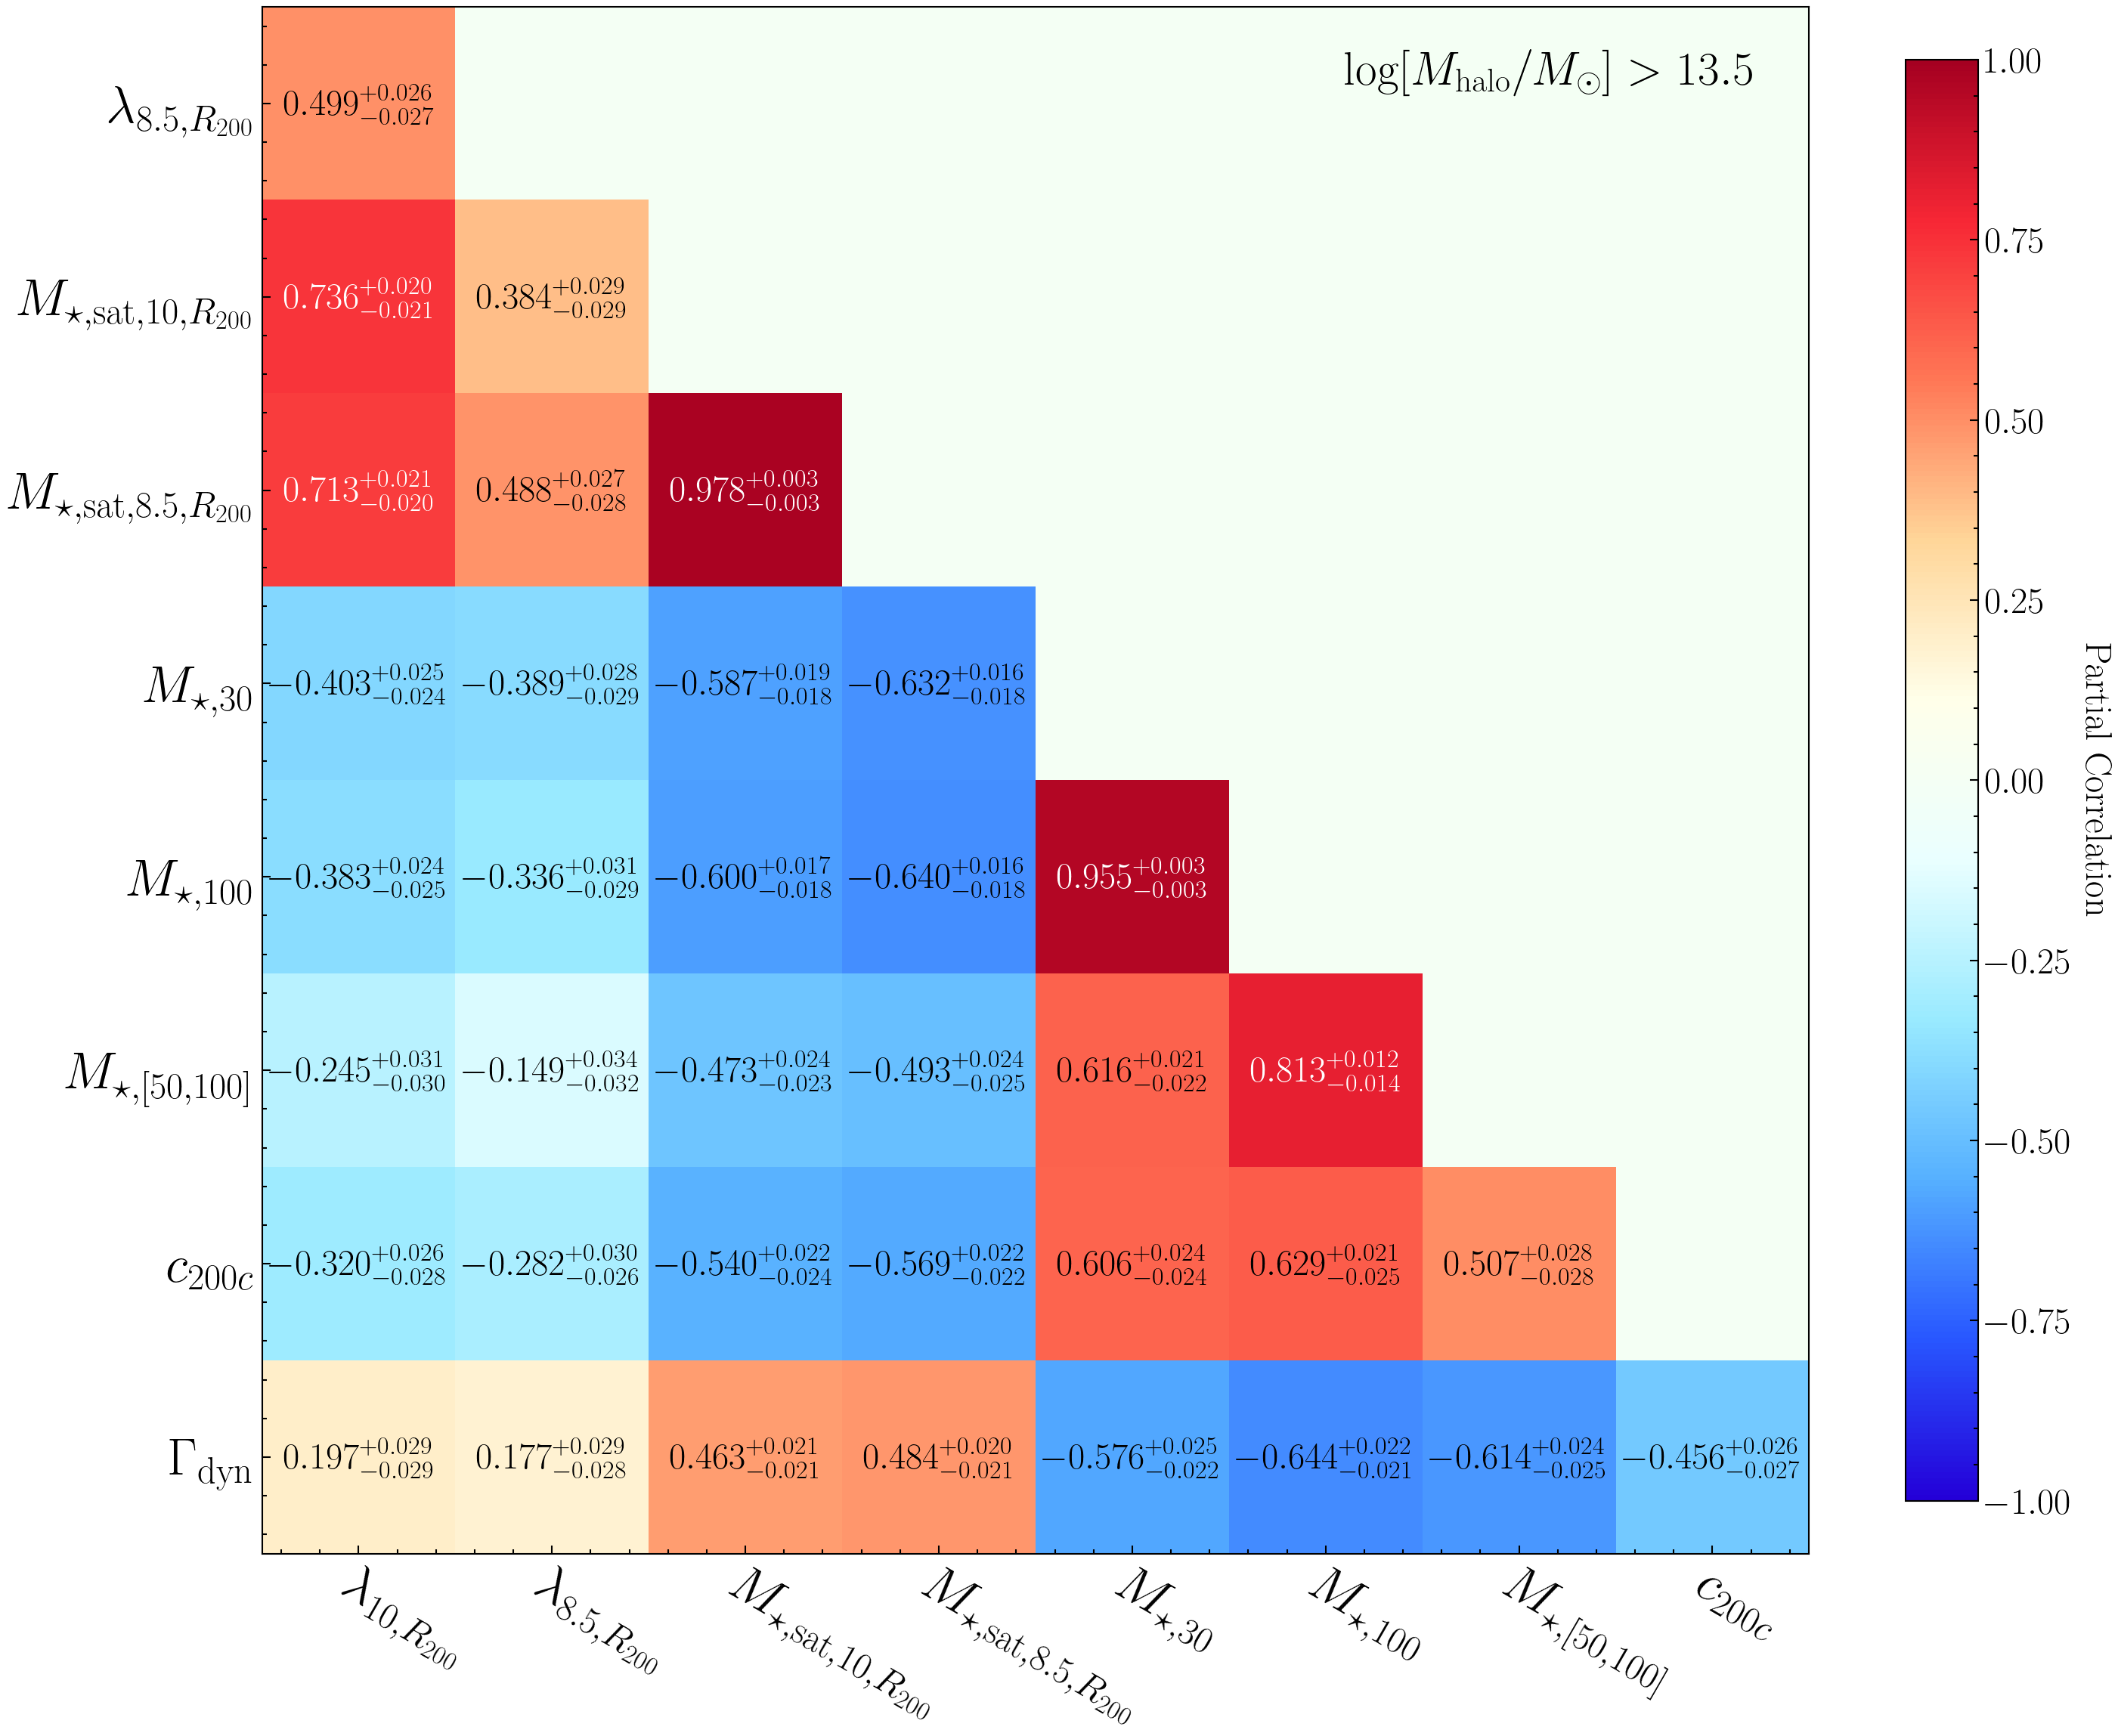

In [16]:
fig=plt.figure(figsize=(30,30))
gs = fig.add_gridspec(1,1, hspace=0, wspace=0)
ax= gs.subplots(sharex='col', sharey='row')


im, cbar = heatmap(np.asarray(partial_corr_f), np.asarray(list0[1:]) , np.asarray(list0[:-1]), ax=ax,fontsize=50,
                   cmap=cmap1, cbarlabel=r"\rm Partial Correlation",cbar_kw={'shrink':0.66},vmin=-1,vmax=1)
texts = annotate_heatmap(im,im_error=im_error,threshold=0.7,valfmt="{x:.3f}",textcolors=('black','white'))

ax.text(0.7,0.95,r'$\log[M_{\rm halo}/M_\odot]>13.5$',transform=ax.transAxes,fontsize=45)

fig.tight_layout()
plt.savefig(fig_dir+"Fig4.pdf",dpi=150,bbox_inches='tight')

In [12]:
mask1=(tab2['c_200c']<15)&(tab2['richness_cut_r200_10']>0)&(tab2['mass_halo']>10**13.5)&(mask_exl)
c200c=tab2[mask1]['c_200c']
acc_rate=tab2[mask1]['acc_rate']
halo_shape=tab2[mask1]['c_to_a_3d']
log_mass_halo=np.log10(tab2[mask1]['mass_halo'])
log_richness_10=np.log10(tab2[mask1]['richness_cut_r200_10'])
log_richness_8=np.log10(tab2[mask1]['richness_cut_r200_8.5'])
log_sat_mass_10=np.log10(tab2[mask1]['satellite_mass_cut_r200_10'])
log_sat_mass_8=np.log10(tab2[mask1]['satellite_mass_cut_r200_8.5'])
log_mass_30=np.log10(tab2[mask1]['aper_30_gal'])
log_mass_100=np.log10(tab2[mask1]['aper_100_gal'])
log_mass_50_100=np.log10(tab2[mask1]['aper_100_gal']-tab2[mask1]['aper_50_gal'])
name_list=(r"$M_{\rm halo}$",r"$\lambda_{10,R_{200}}$",r"$\lambda_{8.5,R_{200}}$",r'$M_{\star,{\rm sat},10,R_{200}}$',r'$M_{\star,{\rm sat},8.5,R_{200}}$',r'$M_{\star,30}$',r'$M_{\star,100}$',r'$M_{\star,[50,100]}$',r"$c_{200c}$",r"$\Gamma_{\rm dyn}$")
tab_x=QTable([log_mass_halo,log_richness_10,log_richness_8,log_sat_mass_10,log_sat_mass_8,log_mass_30,log_mass_100,log_mass_50_100,c200c,acc_rate],names=name_list)
tab_pd=tab_x.to_pandas()
list0=name_list[1:]
partial_corr_f=[]
partial_corr_up=[]
partial_corr_down=[]
for i in range(len(list0)-1):
    partial_corr_f.append([])
    partial_corr_up.append([])
    partial_corr_down.append([])
    for j in range(len(list0)-1):
        if i>=j:
            xdata=list0[i+1]
            ydata=list0[j]
            listm=[]
            listm.append(r"$M_{\rm halo}$")
            corr=pg.partial_corr(data=tab_pd,x=xdata,y=ydata,covar=listm,method='spearman')
            mean_corr,corr_up,corr_down=bootstrap_partial_corr(tab_pd,xdata,ydata,listm,method='spearman',times=1500)
            partial_corr_f[i].append(corr['r'][0])
            partial_corr_up[i].append(corr_up-corr['r'][0])
            partial_corr_down[i].append(corr['r'][0]-corr_down)
        else:
            partial_corr_f[i].append(0)
            partial_corr_up[i].append(0)
            partial_corr_down[i].append(0)
im_error=np.asarray([partial_corr_up,partial_corr_down])


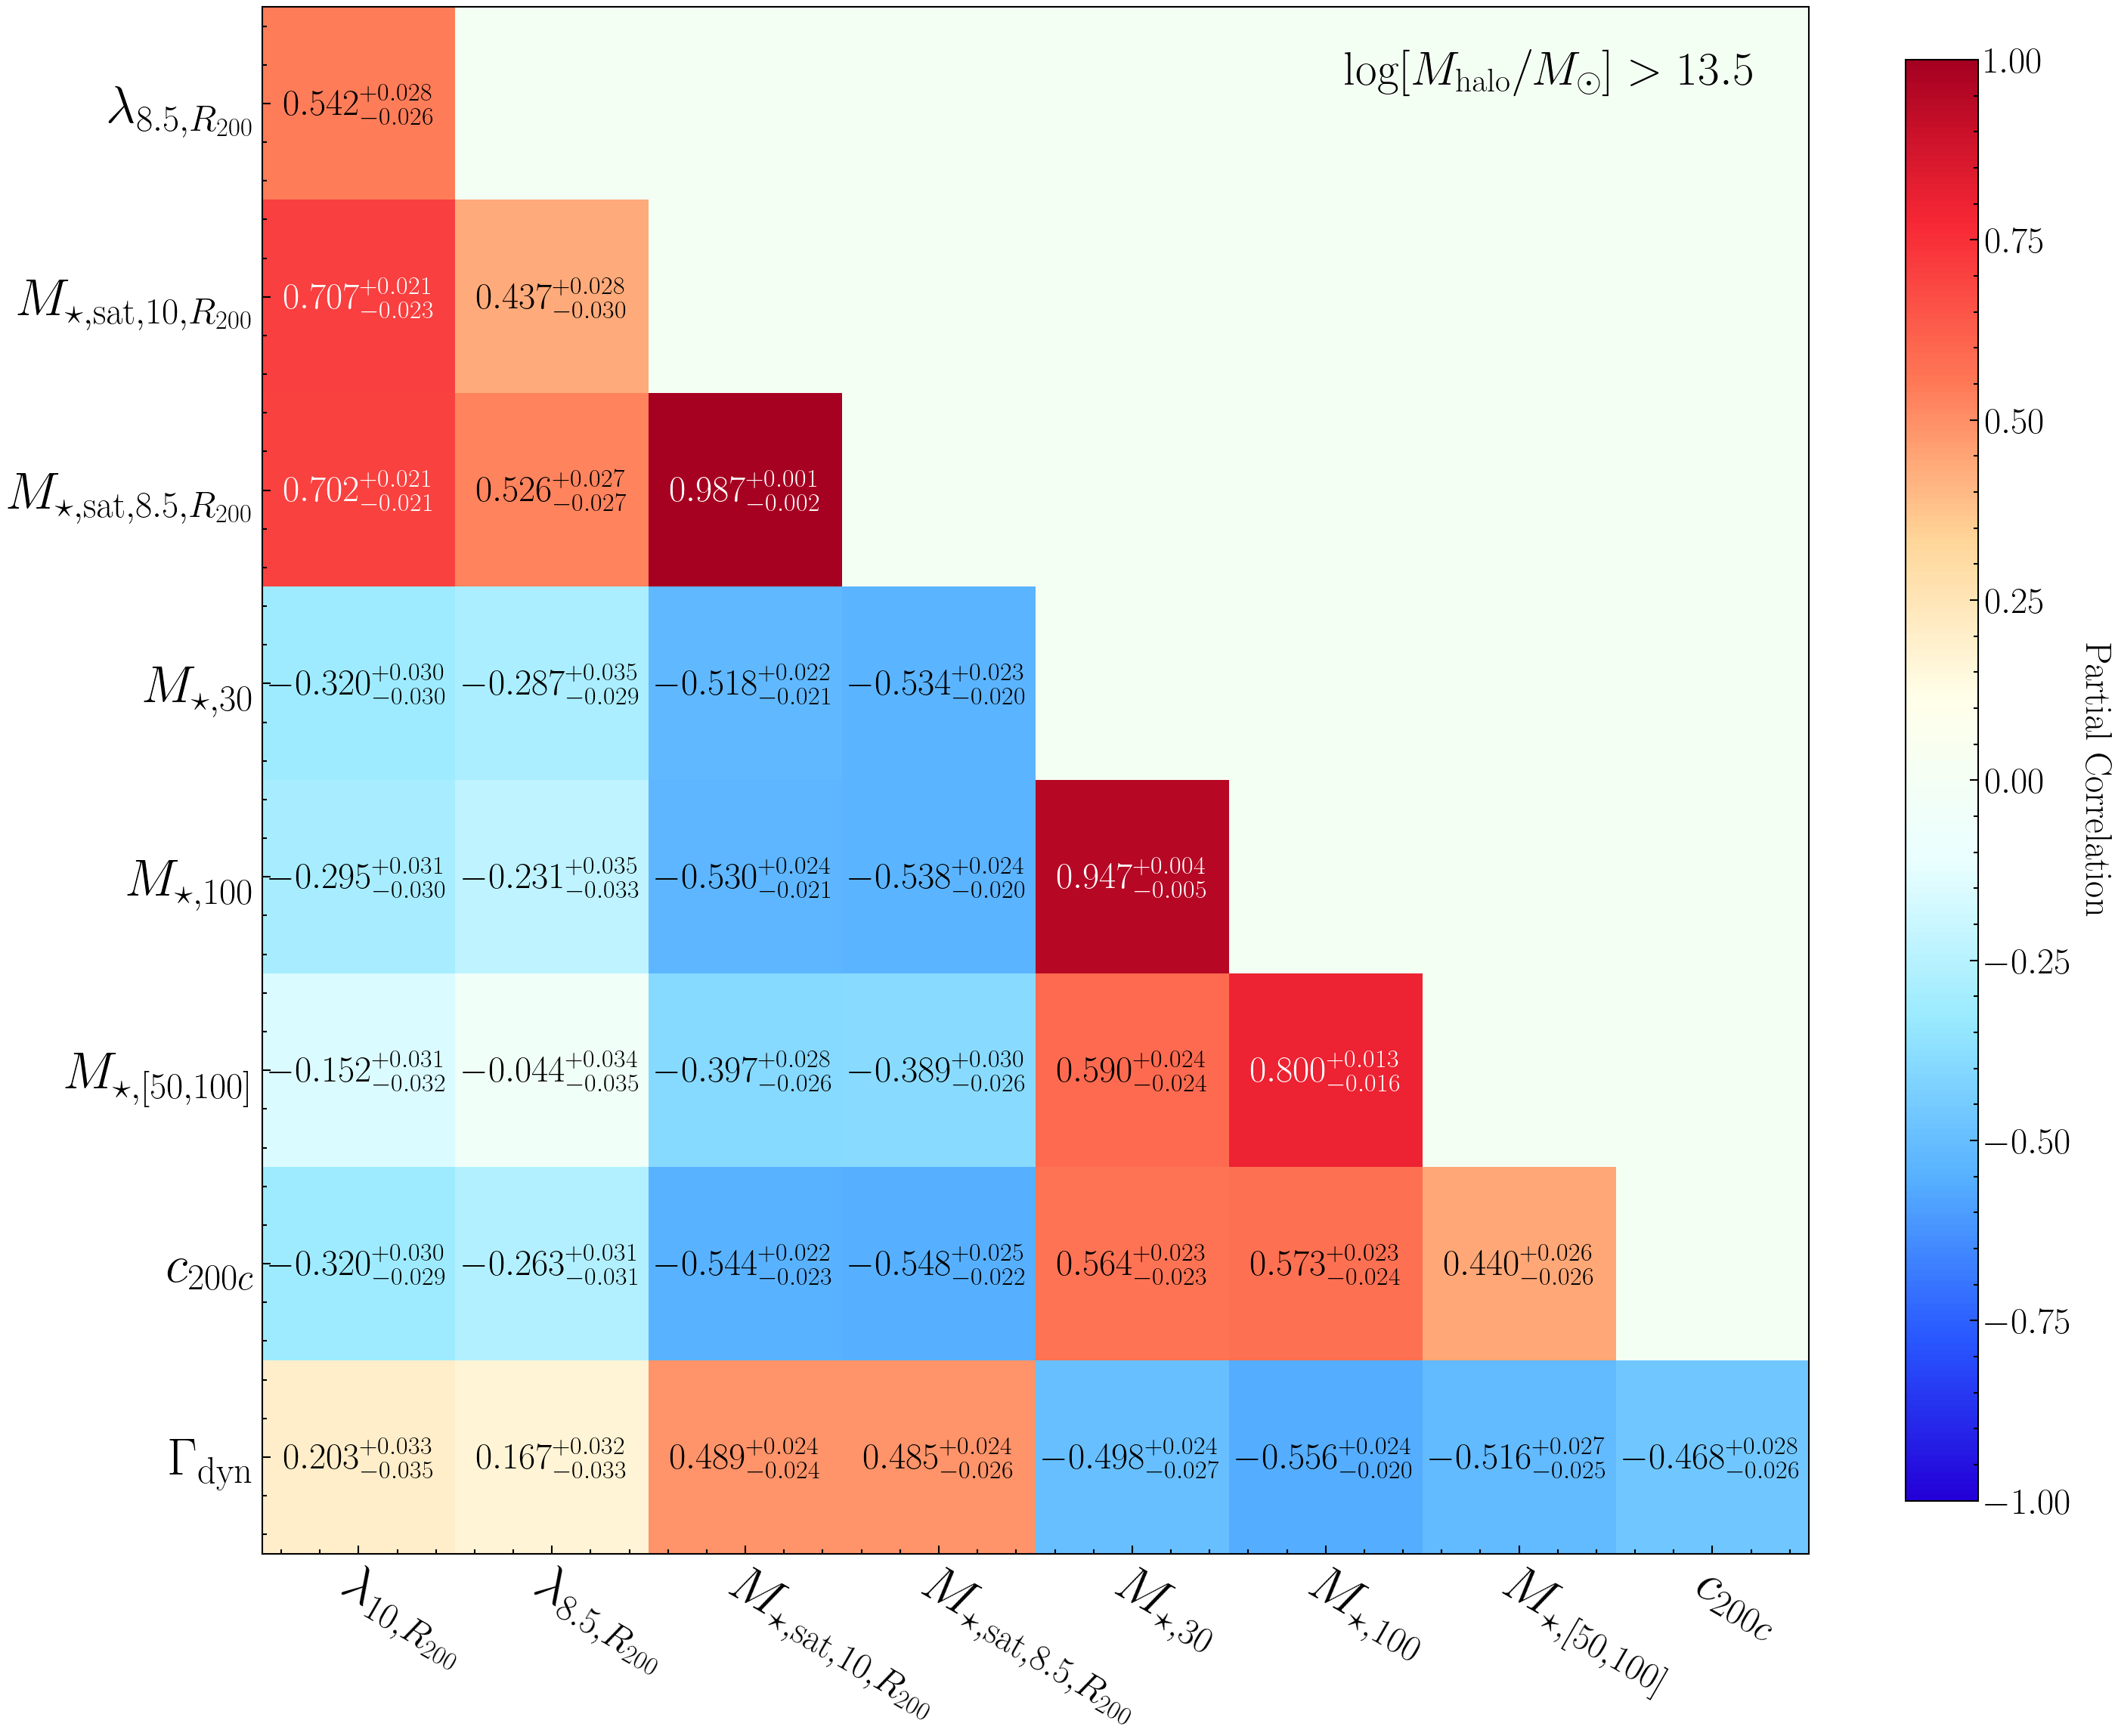

In [13]:
fig=plt.figure(figsize=(30,30))
gs = fig.add_gridspec(1,1, hspace=0, wspace=0)
ax= gs.subplots(sharex='col', sharey='row')


im, cbar = heatmap(np.asarray(partial_corr_f), np.asarray(list0[1:]) , np.asarray(list0[:-1]), ax=ax,fontsize=50,
                   cmap=cmap1, cbarlabel=r"\rm Partial Correlation",cbar_kw={'shrink':0.66},vmin=-1,vmax=1)
texts = annotate_heatmap(im,im_error=im_error,threshold=0.7,valfmt="{x:.3f}",textcolors=('black','white'))

ax.text(0.7,0.95,r'$\log[M_{\rm halo}/M_\odot]>13.5$',transform=ax.transAxes,fontsize=45)

fig.tight_layout()
plt.savefig(fig_dir+"RepFig4Spearman.pdf",dpi=150,bbox_inches='tight')